In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
commonpath='~/ProjectsPy/PyCharm/codetoshare/results_csv/'
import matplotlib
from matplotlib.backends.backend_pgf import FigureCanvasPgf
#matplotlib.backend_bases.register_backend('pdf', FigureCanvasPgf)

from matplotlib.gridspec import GridSpec
import re

#dataname='hyperpartisan'

In [80]:
dataname1='hyperpartisan'
test_data_path1='../data/%s/%s-test.csv'%(dataname1, dataname1)
hyp=pd.read_csv(test_data_path1)
hyp.head(2)
#print(hyp['category'].value_counts())
labels={0: 'False', 1: 'True'}
cls=0
classname=False  #labels[cls]
print('Index options for selected class are: \n', hyp[['text','label']].loc[hyp['label']==classname].iloc[:12])

Index options for selected class are: 
                                                  text  label
0   Former FBI director James Comey speaks during ...  False
1   President Trump responded to the Senate Republ...  False
2   The NFL national anthem story isn’t going away...  False
5   UPDATE May 22, 2018: The Little Rock Police De...  False
6   Members of the Dallas Cowboys organization hav...  False
8   It's a debate playing out across America. Shou...  False
9   President Barack Obama is set to speak at the ...  False
12  Former Dems Now Backing Trump: 'Our Country's ...  False
14  Rumors that Jennifer Aniston and Justin Therou...  False
15  The hotel security guard wounded in the Las Ve...  False
17  Image copyright 2014 Getty Images. All rights ...  False
18  Hillary Clinton apparently can't escape the " ...  False


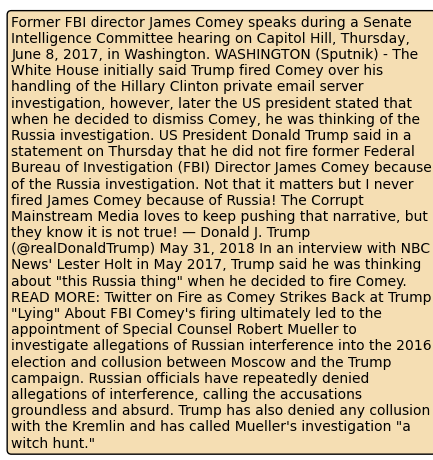

In [82]:
text_w,text_h=11,12
idx=0
fig,axis=plt.subplots(1,1,figsize=(text_w*cm,text_h*cm), layout="tight")
props = dict(boxstyle='round', facecolor='wheat')
axis.text(-0.1, 1, hyp['text'].loc[hyp['label']==classname].iloc[0], bbox=props, wrap=True,  ha='left',
          va='top', fontsize=10, transform=axis.transAxes)

#plt.show()
figpath='../pics/'
figname=figpath+'%s_cls%s_idx%d.pdf'%(dataname1, cls, idx)
fig.savefig(figname, bbox_inches='tight', dpi=300)


In [41]:
hyp_all.head(3)

,Words,impact-FALSE,impact-TRUE,impact-Net
0,donald,0.010748,0.001125,0.009623
1,interference,0.011731,0.008298,0.003432
2,james,0.011456,0.003374,0.008082


../pics/hyperpartisan_10words_Impact_1_idx0.pdf


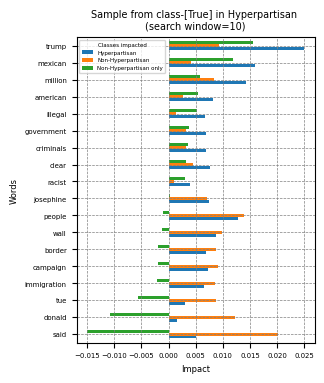

In [39]:
#imp_all.sort_values(by='NetImpact', ascending=False, inplace=True)
#imp_display.rename(columns={'NegImpact':'Negative', 'PosImpact': 'Positive','NetImpact':'Net'}, inplace=True)
labels=['false','true']
dataname1, idx, cls ='hyperpartisan', 0, 1
n_top_words=10

hyp_all=pd.read_csv(commonpath+'%s_top%d_words_cls%d_idx%d.csv'%(dataname1,n_top_words, cls, idx), sep=',')
hyp_all.sort_values(by='impact-Net', inplace=True)
hyp_all.rename(columns={'Unnamed: 0':'Words', 'impact-FALSE': 'Non-Hyperpartisan', 'impact-TRUE': 'Hyperpartisan',
                       'impact-Net':'Non-Hyperpartisan only'}, inplace=True)		
imp_display1=hyp_all.iloc[:80]
#imp_display1.rename(columns={'Positive':'Hyperpartisan', 'Negative-false':'Not Hyperpartisan'}, inplace=True)
imp_display1.set_index('Words', inplace=True)
cm = 1/2.54  # centimeters in inches
fs_title, fs_others=7, 5
fg_w,fg_h= 8.5, 10
fg1,axis1=plt.subplots(figsize=(fg_w*cm,fg_h*cm), layout="tight")
#ax=
imp_display1.plot.barh(ax=axis1)
axis1.set_ylabel('Words', fontsize=fs_title-1)
#axis1.set_xticklabels(hyp_all.index, fontsize=fs_others-1)
axis1.set_yticklabels(imp_display1.index, fontsize=fs_others)
axis1.set_xlabel('Impact', fontsize=fs_title-1)
axis1.set_title('Sample from class-[%s] in %s \n(search window=%d)'%(labels[cls].capitalize(), dataname1.capitalize(), n_top_words), fontsize=fs_title)
#axis1.set_xticks(fontsize=fs_others)
#for tick in axis1.get_xticklabels():
    #tick(fontsize=fs_others+3)#.set_rotation(45)
#axis1.legend(loc='best', fontsize=fs_others-2)
axis1.grid(color='gray', linestyle='dashed', linewidth = 0.5) #, zorder=0)#.grid(zorder=0)
#axis1.legend(, fontsize=fs_others)
#
figpath='../pics/'
figname1=figpath+'%s_%dwords_Impact_%s_idx%d.pdf'%(dataname1,n_top_words,cls, idx)
#plt.set_size_inches(fg_w*cm,fg_h*cm)
#plt.xticks(fontsize=fs_others)
axis1.legend(loc='upper left',title='Classes impacted', fontsize=fs_others-1, title_fontsize=fs_others-1) #, bbox_to_anchor=(1.0, 1.0))
axis1.tick_params(axis='both', which='major', labelsize=fs_others)
plt.savefig(figname1, bbox_inches='tight', dpi=300)
print(figname1)
#hyp_display.plot.barh(x='Words', y='NetImpact', figsize=(5,5))

In [107]:
dataname2='reuters-8'
test_data_path='../data/%s/%s-test.csv'%(dataname2, dataname2)
reut=pd.read_csv(test_data_path)
reut.head(2)
print(reut['category'].value_counts())
labels={0: 'acq', 1: 'crude', 2: 'earn', 3: 'grain', 4: 'interest', 5: 'money-fx', 6: 'ship', 7: 'trade'}
cls=2
category=labels[cls]
print('Index options for selected class are: \n', reut[['text','category']].loc[reut['category']==category].iloc[:50]) #.to_numpy())

category
earn        1083
acq          696
crude        121
money-fx      87
interest      81
trade         75
ship          36
grain         10
Name: count, dtype: int64
Index options for selected class are: 
                                                  text category
4   amatil proposes two for bonus share issue amat...     earn
5   bowater pretax profits rise mln stg shr div ma...     earn
7   bowater industries profit exceed expectations ...     earn
8   citibank norway unit loses six mln crowns citi...     earn
9   vieille montagne conditions unfavourable sharp...     earn
10  vieille montagne reports loss dividend nil yea...     earn
13  jardine matheson sets two for bonus issue repl...     earn
15  isuzu plans interim dividend isuzu motor isum ...     earn
19  jardine matheson replaces share bonus issue ja...     earn
22  italy fondiaria report higher profits italian ...     earn
23  higher profit for dutch chemical firm dsm full...     earn
25  california biotech cbio sees 

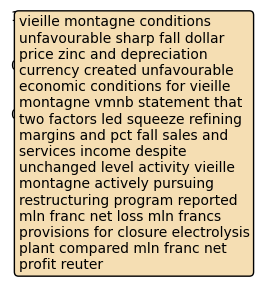

In [116]:
text_w,text_h=7,6
idx=4
fig,axis=plt.subplots(1,1,figsize=(text_w*cm,text_h*cm), layout="tight")
props = dict(boxstyle='round', facecolor='wheat')
axis.text(-0.15, 1, reut['text'].loc[reut['label']==cls].iloc[idx], bbox=props, wrap=True,  ha='left',
          va='top', fontsize=10, transform=axis.transAxes)

#plt.show()
figpath='../pics/'
figname=figpath+'%s_cls%s_idx%d.pdf'%(dataname2, cls, idx)
fig.savefig(figname, bbox_inches='tight', dpi=300)

     Words  impact-EARN  impact-CRUDE  impact-Net
3      oil     0.008871      0.084669   -0.075799
5  foreign     0.005316      0.033927   -0.028611
8   norway     0.002641      0.024949   -0.022308
6   barrel     0.004047      0.014862   -0.010815
EARN
             EARN     CRUDE  EARN but not CRUDE
Words                                          
oil      0.008871  0.084669           -0.075799
foreign  0.005316  0.033927           -0.028611
norway   0.002641  0.024949           -0.022308
barrel   0.004047  0.014862           -0.010815


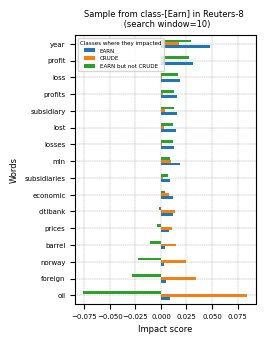

In [115]:
n_top_words=10
reut_all=pd.read_csv(commonpath+'%s_top%d_words_cls%d_idx%d.csv'%(dataname2,n_top_words, cls, idx), sep=',')
reut_all.rename(columns={'Unnamed: 0':'Words'}, inplace=True)		
#imp_display2.rename(columns={'Positive':'Positive-'+category.capitalize()},# 'Negative':'Negative-'+category}, inplace=True)
reut_all.sort_values(by='impact-Net', inplace=True)
imp_display2=reut_all.copy()
print(imp_display2.head(4))
imp_display2.set_index('Words', inplace=True)
print(imp_display2.columns[0].split('-')[1])
imp_display2.rename(columns={imp_display2.columns[0] : imp_display2.columns[0].split('-')[1],
                    imp_display2.columns[1] : imp_display2.columns[1].split('-')[1],
                    imp_display2.columns[2] : imp_display2.columns[0].split('-')[1]+ ' but not '+ imp_display2.columns[1].split('-')[1]}, inplace=True)
cm = 1/2.54  # centimeters in inches
fg_w,fg_h= 7,9
fs_title, fs_others=6,5
print(imp_display2.head(4))
fg2,axis2=plt.subplots(figsize=(fg_w*cm,fg_h*cm), layout="tight")
#ax=
imp_display2.plot.barh(ax=axis2)
axis2.set_ylabel('Words', fontsize=fs_title)
axis2.set_xlabel('Impact score', fontsize=fs_title)
axis2.set_title('Sample from class-[%s] in %s \n (search window=%d)'%(category.capitalize(), dataname2.capitalize(), n_top_words), fontsize=fs_title)
#axis.set_xticks(rotation=45, ha='right')
axis2.set_yticklabels(imp_display2.index, fontsize=fs_others)
axis2.grid(color='gray', linestyle='dashed', linewidth = 0.25) #,
#axis2.legend(bbox_to_anchor=(1.0, 1.0), fontsize=fs_others)
axis2.legend(loc='upper left',title='Classes where they impacted', fontsize=fs_others-1, title_fontsize=fs_others-1)
axis2.tick_params(axis='both', which='major', labelsize=fs_others)
figpath='../pics/'
figname2=figpath+'%s_%dwords_Impact_cls%s_idx%d_Long.pdf'%(dataname2,n_top_words, cls, idx)
#plt.set_size_inches(fg_w*cm,fg_h*cm)
plt.savefig(figname2, bbox_inches='tight', dpi=300, pad_inches=0)

In [51]:
sample_text=reut['text'].loc[reut['label']==cls].iloc[idx]
#words=reut_all[reut_all['Impact-Net'>0]].index:
#replaced = re.sub(word, {Fore.GREEN}, sample_text)
print(reut_all.head(3))

      Words  impact-CRUDE  impact-EARN  impact-Net
17   record      0.002691     0.027171   -0.024480
6    growth      0.005939     0.023672   -0.017733
3   profits      0.001572     0.010464   -0.008892


In [52]:
from colorama import Fore
replaced=sample_text

#for word in reut_all[reut_all['impact-Net']>0].index:
#    matches=re.findall(r'\b%s\b'%(word), sample_text)
#    for match in matches:
        #replaced = re.sub(r'\b%s\b'%(match), str("\textcolor{green}{'\b%s\b'%(match)}"), replaced)
#        replaced = re.sub(r'\b%s\b'%(match), r'\\textcolor{green}{"%s"%(match)}', replaced)

for word in reut_all['Words'].loc[reut_all['impact-Net']<=0].index:
    matches=re.findall(r'\b%s\b'%(word), sample_text)
    for match in matches:
        replaced = re.sub(r'\b%s\b'%(match), f'{Fore.RED}'+match+f'{Fore.BLACK}', replaced)    
for word in reut_all['Words'].loc[reut_all['impact-Net']>0].index:
    matches=re.findall(r'\b%s\b'%(word), sample_text)
    for match in matches:
        replaced = re.sub(r'\b%s\b'%(match), f'{Fore.GREEN}'+match+f'{Fore.BLACK}', replaced)   
#print(replaced)
print(replaced)

oil dependency rising record level united states dependency foreign oil sources reach record levels mid john lichtblau president petroleum industry research associates lichtblau speaking alternative energy conference depend foreign suppliers for pct oil surpasssing previous high level pct long term growth dependency foreign oil inevitable lichtblau pct oil imports come opec nations lichtblau depended foreign suppliers for pct oil and predicted that increase pct rate this growth can affected positively negatively government action inaction lichtblau that government negative actions maintenance windfall profits tax acts disincentive developing existing fields and reduces cash flow for oil exploration lichtblau called for adoption international floor price for crude oil stabilize world oil prices international floor price adopted industrial countries effective measure and distortive for imposed alone lichtblau development alternate energy sources such synthetic fuels increased development

In [ ]:
#!pip install colorama
#from operator import itemgetter
#from colorama import Fore
#print(f"{Fore.RED}This text{Fore.WHITE} is red!. But this text is {Fore.GREEN} green.{Fore.WHITE} ")
all_words=sample_text.split()
default_col=['black']*len(sample_text.split())
df_temp=pd.DataFrame(data={'text':all_words, 'col':default_col})
#print(default_col)
for word in reut_all[reut_all['impact-Net']>0].index:
    matches=re.findall(r'\b%s\b'%(word), sample_text)
    #iters = re.finditer(r'\b%s\b'%(word), sample_text)
    df_temp['col'].loc[df_temp['text'].str.contains('|'.join(matches))]='green'
for word in reut_all[reut_all['impact-Net']<0].index:
    matches=re.findall(r'\b%s\b'%(word), sample_text)
    #iters = re.finditer(r'\b%s\b'%(word), sample_text)
    df_temp['col'].loc[df_temp['text'].str.contains('|'.join(matches))]='red'
    #new_list = [new_item if item == old_item else item for item in original_list]
    #for iter in iters:
        #default_col[iter]='green'
        
        #replaced = re.sub(r'\b%s\b'%(match), str("\textcolor{green}{'\b%s\b'%(match)}"), replaced)
        #iter = re.finditer(r'\b%s\b'%(match), match)
        #indices = [m.start(0) for m in iter]
        #replaced = re.sub(r'\b%s\b'%(match), r'\\textcolor{green}{"%s"%(match)}', replaced)
df_temp

In [ ]:
all_words, default_cols=df_temp['text'].to_list(), df_temp['col'].to_list()
from matplotlib.offsetbox import TextArea, VPacker, AnnotationBbox
from pylab import *
fig = figure(1)
ax = gca()
Texts = []
for t,c in zip(all_words,default_cols):
    Texts.append(TextArea(t,textprops=dict(color=c)))
    
texts_vbox = VPacker(children=Texts,pad=0,sep=0)
ann = AnnotationBbox(texts_vbox,(.5,.5),xycoords=ax.transAxes,
                            box_alignment=(0,.5),bboxprops = 
                            dict(facecolor='wheat',boxstyle='round',color='white'))
ann.set_figure(fig)
fig.artists.append(ann)

In [ ]:
#!pip install text_to_image
#import text_to_image
#!pip install latex
t=print(str(replaced))
import sys
plt.figure(figsize=(0, 0), dpi=80)

f = open("test-text.png", 'w')
sys.stdout = f
print(replaced)
f.close()

In [ ]:
import PIL
from PIL import (
    Image,
    ImageFont,
    ImageDraw,
)
import PIL.ImageOps

PIXEL_ON = 0  # PIL color to use for "on"
PIXEL_OFF = 255  # PIL color to use for "off"

def text_image(text, font_path=None):
    """Convert text to a grayscale image with black characters on a white background.
    arguments:
    text_path - the content of this file will be converted to an image
    font_path - path to a font file (for example impact.ttf)
    """
    grayscale = 'L'
    # parse the file into lines
    lines = tuple(l.rstrip() for l in text.splitlines())
    # choose a font (you can see more detail in my library on github)
    large_font = 40  # get better resolution with larger size
    font_path = font_path or 'cour.ttf'  # Courier New. works in windows. linux may need more explicit path
    try:
        font = PIL.ImageFont.truetype(font_path, size=large_font)
    except IOError:
        font = PIL.ImageFont.load_default()
        print('Could not use chosen font. Using default.')
    # make the background image based on the combination of font and lines
    pt2px = lambda pt: int(round(pt * 96.0 / 72))  # convert points to pixels
    max_width_line = max(lines, key=lambda s: font.getsize(s)[0])
    # max height is adjusted down because it's too large visually for spacing
    test_string = 'ABCDEFGHIJKLMNOPQRSTUVWXYZ'
    max_height = pt2px(font.getsize(test_string)[1])
    max_width = pt2px(font.getsize(max_width_line)[0])
    height = max_height * len(lines)  # perfect or a little oversized
    width = int(round(max_width + 40))  # a little oversized
    image = PIL.Image.new(grayscale, (width, height), color=PIXEL_OFF)
    draw = PIL.ImageDraw.Draw(image)
    # draw each line of text
    vertical_position = 5
    horizontal_position = 5
    line_spacing = int(round(max_height * 0.8))  # reduced spacing seems better
    for line in lines:
        draw.text((horizontal_position, vertical_position),
                  line, fill=PIXEL_ON, font=font)
        vertical_position += line_spacing
    # crop the text
    c_box = PIL.ImageOps.invert(image).getbbox()
    image = image.crop(c_box)
    return image

def main():
    
    image = text_image(str(t))
    image.show()
    image.save("test.png")

if __name__ == '__main__':
    main()

In [ ]:
t=print(replaced)
#str(t)

In [ ]:
t

In [ ]:
len(sample_text.split(' '))